In [6]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import math
import matplotlib.pyplot as plt
import statsmodels.api as sm

Генерация выборки

In [7]:
# Фиксируем random seed для воспроизводимости
np.random.seed(42)

n = 50

# Генерация xi_k ~ Uniform(-1, 1)
xi1 = np.random.uniform(-1, 1, n)
xi2 = np.random.uniform(-1, 1, n)
xi3 = np.random.uniform(-1, 1, n)
xi4 = np.random.uniform(-1, 1, n)
xi5 = np.random.uniform(-1, 1, n)

# Матожидание eta
mu_eta = 2 + 3*xi1 - 2*xi2 + xi3 + xi4 - xi5
eta = np.random.normal(loc=mu_eta, scale=1.5, size=n)

# Собираем в DataFrame
data = pd.DataFrame({
    'xi1': xi1, 'xi2': xi2, 'xi3': xi3, 'xi4': xi4, 'xi5': xi5,
    'eta': eta
})
print(data)

         xi1       xi2       xi3       xi4       xi5       eta
0  -0.250920  0.939169 -0.937142  0.816532  0.284063 -2.305962
1   0.901429  0.550266  0.272821 -0.520876 -0.831720  1.915148
2   0.463988  0.878998 -0.371288 -0.710210 -0.676743  0.559440
3   0.197317  0.789655  0.017141 -0.021094  0.797108  1.496178
4  -0.687963  0.195800  0.815133  0.971301  0.212858  1.439228
5  -0.688011  0.843748 -0.501416 -0.515889 -0.981606 -3.655837
6  -0.883833 -0.823015 -0.179234  0.344271 -0.797057  2.216397
7   0.732352 -0.608034  0.511102  0.523239  0.327004  6.698439
8   0.202230 -0.909545 -0.542404 -0.524725 -0.989877  3.022743
9   0.416145 -0.349339 -0.846040  0.456433 -0.678384  4.466478
10 -0.958831 -0.222645 -0.420497 -0.264434  0.097468 -1.126288
11  0.939820 -0.457302 -0.677557  0.264612  0.383790  3.222871
12  0.664885  0.657475  0.859395  0.267059  0.303923  4.038919
13 -0.575322 -0.286493  0.616241  0.071549 -0.551461  2.927450
14 -0.636350 -0.438131  0.266808 -0.819420  0.424358  1

ПУНКТ а. проверка мультиколлениарности

In [8]:
# Берём только факторы
X = data[['xi1', 'xi2', 'xi3', 'xi4', 'xi5']]

# Словарь для хранения R² каждой вспомогательной регрессии
r2_dict = {}
problem_vars = []

# Перебираем каждую переменную как потенциальный "отклик"
for col in X.columns:
    # Отклик = текущий фактор
    y = X[col]
    
    # Предикторы = все остальные переменные
    X_others = X.drop(columns=[col])
    
    # Добавляем константу (свободный член) в предикторы
    X_others_with_const = sm.add_constant(X_others)
    
    # Строим вспомогательную регрессию
    model_aux = sm.OLS(y, X_others_with_const).fit()
    
    # Получаем R²
    r2 = model_aux.rsquared
    r2_dict[col] = r2
    
    # Проверяем порог 0.7
    if r2 > 0.7:
        problem_vars.append(col)
        status = "мультиколлениарность присутсвует"
    else:
        status = "мультиколлениарность отсутсвует"
    
    print(f"\nВспомогательная регрессия для {col}")
    print(f"  R² = {r2:.4f}  {status}")
    
# Итоговый вывод
if problem_vars:
    print(f"ВЫВОД: Обнаружена мультиколлинеарность для факторов: {problem_vars}")
else:
    print("\nВЫВОД: Мультиколлинеарности нет.")


Вспомогательная регрессия для xi1
  R² = 0.0176  мультиколлениарность отсутсвует

Вспомогательная регрессия для xi2
  R² = 0.0151  мультиколлениарность отсутсвует

Вспомогательная регрессия для xi3
  R² = 0.0655  мультиколлениарность отсутсвует

Вспомогательная регрессия для xi4
  R² = 0.1155  мультиколлениарность отсутсвует

Вспомогательная регрессия для xi5
  R² = 0.0800  мультиколлениарность отсутсвует

ВЫВОД: Мультиколлинеарности нет.


ПУНКТ b. получчение формулы линейной регрессии + оценка значимости коэффициентов.

In [9]:
# 1. Строим Ψ
X = data[['xi1', 'xi2', 'xi3', 'xi4', 'xi5']].values
N = X.shape[0]  # 50

# Добавляем столбец единиц слева
Psi = np.hstack([np.ones((N, 1)), X])   # (50, 6)

# 2. Вектор отклика Y (eta)
Y = data['eta'].values  # (50,)

# 3. Вычисляем оценки коэффициентов по формуле β̃ = (ΨᵀΨ)⁻¹ Ψᵀ Y
F = Psi.T @ Psi
F_inv = np.linalg.inv(F)
b_manual = F_inv @ Psi.T @ Y

# Выводим результаты
print("Оценки коэффициентов (β̃):")
print(f"  const = {b_manual[0]:.4f}")
print(f"  xi1   = {b_manual[1]:.4f}")
print(f"  xi2   = {b_manual[2]:.4f}")
print(f"  xi3   = {b_manual[3]:.4f}")
print(f"  xi4   = {b_manual[4]:.4f}")
print(f"  xi5   = {b_manual[5]:.4f}")

# 4. Уравнение регрессии
print("\nУравнение регрессии:")
print(f"η̂ = {b_manual[0]:.4f} + {b_manual[1]:.4f}·xi1 + {b_manual[2]:.4f}·xi2 + {b_manual[3]:.4f}·xi3 + {b_manual[4]:.4f}·xi4 + {b_manual[5]:.4f}·xi5")

# 5. Проверка значимости коэффициентов

# значение ошибок e = Y - Ψ·b
Y_pred = Psi @ b_manual
residuals = Y - Y_pred
RSS = residuals @ residuals           # остаточная сумма квадратов
p = Psi.shape[1]                      # число параметров = 6
sigma2_hat = RSS / (N - p)            # оценка σ²

# Ковариационная матрица оценок: cov = σ²·F⁻¹
cov_matrix = sigma2_hat * F_inv
std_errors = np.sqrt(np.diag(cov_matrix))   # стандартные ошибки

# delta
delta = b_manual / std_errors

# p-value (двусторонние)
p_values = 2 * (1 - stats.t.cdf(np.abs(delta), df=N-p))

print("\nПроверка значимости коэффициентов (α=0.05):")
print(f"{'Факторы':<8} {'coef':>8} {'std err':>10} {'delta':>8} {'p-value':>10} {'значим?':>8}")
print("-" * 60)
names = ['const', 'xi1', 'xi2', 'xi3', 'xi4', 'xi5']
for i, name in enumerate(names):
    sig = "да" if p_values[i] < 0.05 else "нет"
    print(f"{name:<8} {b_manual[i]:8.4f} {std_errors[i]:10.4f} {delta[i]:8.3f} {p_values[i]:10.6f} {sig:>5}")

Оценки коэффициентов (β̃):
  const = 2.0386
  xi1   = 2.1723
  xi2   = -1.8433
  xi3   = 1.6622
  xi4   = 1.0402
  xi5   = -1.1444

Уравнение регрессии:
η̂ = 2.0386 + 2.1723·xi1 + -1.8433·xi2 + 1.6622·xi3 + 1.0402·xi4 + -1.1444·xi5

Проверка значимости коэффициентов (α=0.05):
Факторы      coef    std err    delta    p-value  значим?
------------------------------------------------------------
const      2.0386     0.2304    8.846   0.000000    да
xi1        2.1723     0.3969    5.473   0.000002    да
xi2       -1.8433     0.3732   -4.939   0.000012    да
xi3        1.6622     0.3951    4.207   0.000125    да
xi4        1.0402     0.4162    2.499   0.016261    да
xi5       -1.1444     0.3832   -2.986   0.004602    да


ПУНКТ с. Проверка значимости коэффициента детерминации.

In [10]:
# 1. TSS (полная сумма квадратов)
Y_mean = np.mean(Y)
TSS = np.sum((Y - Y_mean) ** 2)

# 2. R²
R2 = 1 - RSS / TSS
R2_adj = 1 - (1 - R2) * (N - 1) / (N - p)   # скорректированный R²

print(f"TSS = {TSS:.4f}")
print(f"RSS = {RSS:.4f}")
print(f"R²  = {R2:.4f}")
print(f"R² adjusted = {R2_adj:.4f}")

# 3. Проверка значимости Коэф детерминации
p = Psi.shape[1]          # число параметров = 6
df_model = p - 1          # степени свободы модели (p-1)
df_resid = N - p          # степени свободы остатков (n-p)

delta = ((TSS - RSS) / df_model) / (RSS / df_resid)

# p-value
p_value_F = 1 - stats.f.cdf(delta, df_model, df_resid)

print("\nПроверка значимости Коэф детерминации:")
print(f"delta = {delta:.4f}")
print(f"p-value = {p_value_F:.6f}")

print("\nВЫВОД:")
if p_value_F < 0.05:
    print("Коэф детерминации значим")
else:
    print("Коэф детерминации не значим")

TSS = 313.2043
RSS = 111.3690
R²  = 0.6444
R² adjusted = 0.6040

Проверка значимости Коэф детерминации:
delta = 15.9483
p-value = 0.000000

ВЫВОД:
Коэф детерминации значим


ПУНКТ d. найти значение в точке x_k = 0 и найти доверительный интервал с betta =0.95

In [11]:
x = np.array([1, 0, 0, 0, 0, 0])
y = np.sum(b_manual * x)
betta = 0.95

# ищем delta - значение для вероятности
delta = stats.t.ppf((1 + betta)/ 2, N - p) * \
    np.sqrt(1 + x @ np.linalg.inv(F) @ x.T) * np.sqrt(RSS / (N - p))

print(f"Значение в точке x_k = 0: {y:.4f}")
print(f"Доверительный интервал: ({(y-delta):.4f}, {(y+delta):.4f})")

Значение в точке x_k = 0: 2.0386
Доверительный интервал: (-1.2012, 5.2784)


ПУНКТ e. Проверить предположение о независисмости распределения ошшибок

In [12]:
# 1. Считаем количество инверсий (j < i, пока e[j] > e[i])
inv_amount = 0
for i in range(N):
    for j in range(i):
        if residuals[j] > residuals[i]:
            inv_amount += 1

print(f"Число инверсий I_n: {inv_amount}")

# 3. delta
delta = (inv_amount - (N * (N - 1) / 4)) / np.sqrt(N ** 3 / 36)

# 4. p-value (двусторонний)
p_value = 2 * (1 - stats.norm.cdf(np.abs(delta)))   # sf = survival function = 1 - cdf

alpha_sign = 0.05

# 6. Вывод
print(f"Δ = {delta:.5f}")
print(f"p-value = {p_value:.5f}")

if p_value > alpha_sign:
    print("\nH₀ не отвергается: ошибки независимы")
else:
    print("\nH₀ отвергается: ошибки зависимы")

Число инверсий I_n: 578
Δ = -0.58548
p-value = 0.55822

H₀ не отвергается: ошибки независимы


ПУНКТ f. проверить предположение о нормальности распределения ошибок.

In [13]:
def F_norm(x, alpha, sigma):
  return 0.5 * (1 + math.erf((x - alpha) / (np.sqrt(2) * sigma)))

e_sorted = sorted(residuals)

# формируем эмпирическую функцию
F_emp = np.array([i for i in range(len(e_sorted) + 1)]) / N

bootstrap_iterations = 50_000

# оценка sigma_2^2
disp_wave_2 = (RSS / (N - p)) ** 0.5

delta_wave = np.sqrt(N) * np.max([max(np.abs(F_norm(e_sorted[i], 0, disp_wave_2) - F_emp[i]),
                                      np.abs(F_norm(e_sorted[i], 0, disp_wave_2) - F_emp[i + 1])) for i in range(N)])

bootstrap_delta = []

for _ in range(bootstrap_iterations):
  # Случайная выборка, соотв норм. распределению
  random_sample = np.array(sorted(np.random.normal(0, disp_wave_2, N)))

  # Оценка мат. ожидания по случайной подвыборке
  alpha_bootstrap = random_sample.mean()

  # Оценка корня дисперсии по случайной подвыборке
  sigma_bootstrap = np.sqrt(random_sample.var() * N / (N - 1))

  F_bootstrap_emp = [i / N for i in range(N + 1)]

  # Функция нормального распределения по случайной подвыборке (стр 35)
  def F_bootstrap_wave(j):
    return F_norm(random_sample[j], alpha_bootstrap, sigma_bootstrap)

  sup = np.max([max(np.abs(F_bootstrap_wave(j) - F_bootstrap_emp[j]),
                    np.abs(F_bootstrap_wave(j) - F_bootstrap_emp[j + 1]))
                for j in range(len(random_sample))])

  bootstrap_delta.append(np.sqrt(N) * sup)

bootstrap_delta = np.array(bootstrap_delta)

p_value = len(bootstrap_delta[bootstrap_delta >=
              delta_wave]) / bootstrap_iterations

print(f"p-value = {p_value}")
if p_value > alpha_sign:
  print("Ошибки распределены нормально")
else:
  print("Ошибки распределены нормально")

p-value = 0.37212
Ошибки распределены нормально


ПУНКТ g. Расчет выбросов

Q1  (25-й перцентиль) = -0.983561
Q2  (50-й перцентиль, медиана) = -0.047927
Q3  (75-й перцентиль) = 1.008461
IQR (Q3 - Q1) = 1.992022

Границы для выбросов:
Нижняя граница (Q1 - 1.5*IQR) = -3.971595
Верхняя граница (Q3 + 1.5*IQR) = 3.996495

Выбросы:
Найдено 1 выбросов:
  Наблюдение 21: остаток = 4.772058


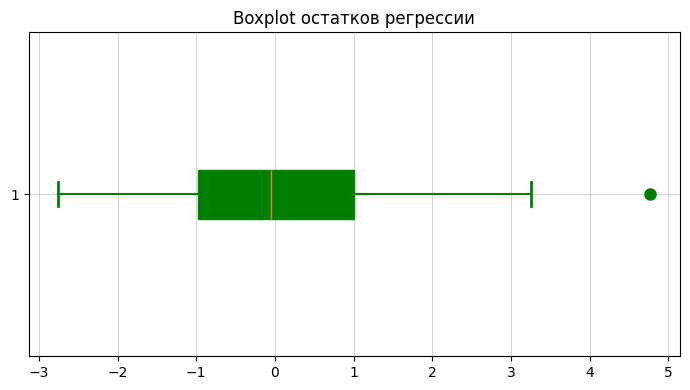

In [14]:
e = residuals.copy()

# 1. Основные данные остатков
Q1 = np.percentile(e, 25)
Q2 = np.median(e)
Q3 = np.percentile(e, 75)
IQR = Q3 - Q1

# 2. Границы для выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Выбросы
outliers_mask = (e < lower_bound) | (e > upper_bound)
outliers_indices = np.where(outliers_mask)[0]
outliers_values = e[outliers_mask]

# 4. Output
print(f"Q1  (25-й перцентиль) = {Q1:.6f}")
print(f"Q2  (50-й перцентиль, медиана) = {Q2:.6f}")
print(f"Q3  (75-й перцентиль) = {Q3:.6f}")
print(f"IQR (Q3 - Q1) = {IQR:.6f}")

print("\nГраницы для выбросов:")
print(f"Нижняя граница (Q1 - 1.5*IQR) = {lower_bound:.6f}")
print(f"Верхняя граница (Q3 + 1.5*IQR) = {upper_bound:.6f}")

print("\nВыбросы:")
if len(outliers_indices) > 0:
    print(f"Найдено {len(outliers_indices)} выбросов:")
    for idx, val in zip(outliers_indices, outliers_values):
        print(f"  Наблюдение {idx}: остаток = {val:.6f}")
else:
    print("  Выбросов не обнаружено")

# 5. Boxplot
fig, ax = plt.subplots(1, 1, figsize=(7, 4))

ax.set_title("Boxplot остатков регрессии")

bp = ax.boxplot(e,
                vert=False,
                patch_artist=True,
                boxprops=dict(facecolor="green", color="green"),
                whiskerprops={"color": "green", "linewidth": 1.5},
                capprops={"color": "green", "linewidth": 2},
                flierprops={'markerfacecolor': 'green', 'markersize': 8, 'markeredgecolor': 'green'})

ax.grid(which='minor', linestyle='--', linewidth=0.2)
ax.grid(which='major', linewidth=0.4)

plt.tight_layout()
plt.show()

ПУНКТ h. Крос-проверка

In [15]:
sample = data[['xi1', 'xi2', 'xi3', 'xi4', 'xi5', 'eta']].values

ksi_amount = 5                     # номер последнего столбца (eta)

CVSS = 0
sample_copy = sample.copy()

for i in range(N):
    # 1. Обучающая выборка: склейка i-1 и i+1 строк
    sample_train = np.vstack([sample_copy[:i, :], sample_copy[i+1:, :]])
    
    # 2. Матрица Ψ для обучающей выборки
    PSI_train = np.hstack([np.ones((N - 1, 1)), sample_train[:, :-1]])
    
    # 3. Отклик для обучающей выборки
    Y_train = sample_train[:, ksi_amount]
    
    # 4. Оценка коэффициентов МНК
    F_train = PSI_train.T @ PSI_train
    b_cv = np.linalg.inv(F_train) @ PSI_train.T @ Y_train
    
    # 5. Вектор x для отложенного наблюдения
    x_test = np.hstack([[1], sample_copy[i, :-1]])   # (6,)
    
    # 6. Предсказание
    y_pred = np.sum(b_cv * x_test)
    
    # 7. Реальное значение
    y_true = sample_copy[i, ksi_amount]
    
    # 8. Накопление ошибки
    CVSS += (y_true - y_pred) ** 2

# 9. R² на кросс-проверке
R2_cv = 1 - CVSS / TSS

print(f"CVSS = {CVSS:.5f}")
print(f"R²_CV = {R2_cv:.5f}")

CVSS = 145.92615
R²_CV = 0.53409


ПУНКТ i. Проверка адекватности ргерессии 5кратным измерением.

In [16]:
l = 5  # число повторных измерений

# 1. Выбираем случайную точку в пространстве факторов
np.random.seed(123)
x_fixed = np.random.uniform(-1, 1, size=ksi_amount)   # 5 чисел от -1 до 1

print(f"Фиксированная точка x* = ({x_fixed[0]:.4f}, {x_fixed[1]:.4f}, {x_fixed[2]:.4f}, {x_fixed[3]:.4f}, {x_fixed[4]:.4f})")

# 2. Истинное среднее η в этой точке (по условию задачи)
mu_true = 2 + 3*x_fixed[0] - 2*x_fixed[1] + x_fixed[2] + x_fixed[3] - x_fixed[4]
sigma_true = 1.5

print(f"Истинное среднее η* = {mu_true:.4f}")

# 3. Генерируем 5 повторных измерений η в этой точке
y_repeated = np.random.normal(loc=mu_true, scale=sigma_true, size=l)

print(f"\nПовторные измерения η*:")
for i, val in enumerate(y_repeated):
    print(f"  y_{i+1} = {val:.4f}")

# 4. Оценка дисперсий
y_mean = np.mean(y_repeated)
sigma2_hat = np.sum((y_repeated - y_mean) ** 2) / (l - 1)

print(f"\nСреднее повторных измерений: {y_mean:.4f}")
print(f"остаточная дисперсия модели (s²_rep): {sigma2_hat:.4f}")

s2_rep = RSS / (N - p)
print(f"дисперсия повторных измерений (σ̂²): {s2_rep:.4f}")

# 6. delta
delta =  s2_rep / sigma2_hat

# 7. Степени свободы
df1 = N - p
df2 = l - 1

# 8. p-value (правосторонний тест)
p_value = 1 - stats.f.cdf(delta, df1, df2)

print(f"\ndelta = {delta:.4f}")
print(f"p-value = {p_value:.4f}")

# 9. Вывод
alpha_sign = 0.05
if p_value > alpha_sign:
    print("\nH₀ не отвергается: модель адекватна")
else:
    print("\nH₀ отвергается: модель неадекватна")

Фиксированная точка x* = (0.3929, -0.4277, -0.5463, 0.1026, 0.4389)
Истинное среднее η* = 3.1517

Повторные измерения η*:
  y_1 = 3.6348
  y_2 = 3.0744
  y_3 = 2.8454
  y_4 = 6.1207
  y_5 = 0.7227

Среднее повторных измерений: 3.2796
остаточная дисперсия модели (s²_rep): 3.7416
дисперсия повторных измерений (σ̂²): 2.5311

delta = 0.6765
p-value = 0.7749

H₀ не отвергается: модель адекватна


Пункт j. Новая жизнь!

In [17]:
p_values_factors = p_values[1:]            # убираем const
names_factors = names[1:]

idx_max = np.argmax(p_values_factors)      # индекс наименее значимого
var_to_drop = names_factors[idx_max]
p_val_max = p_values_factors[idx_max]

print(f"\nНаименее значимый фактор: {var_to_drop} (p-value = {p_val_max:.6f})")

# 2. Определяем, какой удалить
factor_to_col = {'xi1': 0, 'xi2': 1, 'xi3': 2, 'xi4': 3, 'xi5': 4}
drop_col = factor_to_col[var_to_drop]

# 3. Создаём новый массив данных без удалённого фактора
#    Берём все столбцы кроме drop_col, плюс eta (последний)
sample_new = sample[:, [c for c in range(5) if c != drop_col] + [5]]

# 4. Строим новую матрицу Ψ (без удалённого фактора)
Psi_new = np.hstack([np.ones((N, 1)), sample_new[:, :-1]])   # (50, 5)
Y_new = sample_new[:, -1]

# 5. Оцениваем коэффициенты новой модели
F_new = Psi_new.T @ Psi_new
F_inv_new = np.linalg.inv(F_new)
b_new = F_inv_new @ Psi_new.T @ Y_new

# 6. Считаем RSS и R² для новой модели
Y_pred_new = Psi_new @ b_new
residuals_new = Y_new - Y_pred_new
RSS_new = residuals_new @ residuals_new
R2_new = 1 - RSS_new / TSS

print("\n=== Уравнение новой регрессии ===")
coef_names = ['const'] + [f for f in names_factors if f != var_to_drop]
eq_parts = [f"{b_new[0]:.4f}"]
for i, name in enumerate(coef_names[1:]):
    coef = b_new[i+1]
    sign = "+" if coef >= 0 else "-"
    eq_parts.append(f"{sign} {abs(coef):.4f}·{name}")
print(" η̂ = " + " ".join(eq_parts).replace("+ -", "- "))

# 7. Сравнение с исходной моделью
print("\n================== Сравнение моделей ===================")
print(f"{'Показатель':<15} {'Исходная':>15} {'Новая (без ' + var_to_drop + ')':>22}")
print("-" * 55)
print(f"{'R²':<15} {R2:>15.5f} {R2_new:>22.5f}")
print(f"{'RSS':<15} {RSS:>15.5f} {RSS_new:>22.5f}")



# 8.Сравнение вложенных регрессий
#    H₀: удалённый коэффициент = 0
p_old = p                   # 6
p_new = Psi_new.shape[1]    # 5

delta = ((RSS_new - RSS) / (p_old - p_new)) / (RSS / (N - p_old))
p_value_comp = 1 - stats.f.cdf(delta, p_old - p_new, N - p_old)

print(f"\nF-тест для сравнения (H₀: {var_to_drop} незначим):")
print(f"  delta = {delta:.4f}")
print(f"  p-value = {p_value_comp:.6f}")

alpha = 0.05
print("\n\nВЫВОД:")
if p_value_comp > alpha:
    print(f"Удаление {var_to_drop} обосновано (p-value > {alpha})")
else:
    print(f"Удаление {var_to_drop} привело к ухудшению модели (p-value < {alpha})")


Наименее значимый фактор: xi4 (p-value = 0.016261)

=== Уравнение новой регрессии ===
 η̂ = 2.0599 + 2.1877·xi1 - 1.8319·xi2 + 1.4733·xi3 - 0.8816·xi5

================== Сравнение моделей ===================
Показатель             Исходная        Новая (без xi4)
-------------------------------------------------------
R²                      0.64442                0.59395
RSS                   111.36897              127.17570

F-тест для сравнения (H₀: xi4 незначим):
  delta = 6.2450
  p-value = 0.016261


ВЫВОД:
Удаление xi4 привело к ухудшению модели (p-value < 0.05)


ПУНКТ k. Сравнение бутстрапом

In [21]:
# 1. Параметры бутстрапа
bootstrap_iterations = 1000
beta_sign = 0.95
alpha_sign = 1 - beta_sign

# 2. Исходная разность R²
h_wave = R2 - R2_new

# 3. Определяем, какие колонки в упрощённой модели
full_cols = ['xi1', 'xi2', 'xi3', 'xi4', 'xi5']
keep_cols = [col for col in full_cols if col != var_to_drop]

bootstrap_delta = []

for _ in range(bootstrap_iterations):
    # Псевдовыборка с возвращением
    boot_sample = data.sample(n=N, replace=True)
    
    # Полная модель
    b_model = sm.OLS(boot_sample['eta'], sm.add_constant(boot_sample[full_cols])).fit()
    
    # Упрощённая модель
    b_model_new = sm.OLS(boot_sample['eta'], sm.add_constant(boot_sample[keep_cols])).fit()
    
    # собираем дельты
    bootstrap_delta.append(b_model.rsquared - b_model_new.rsquared - h_wave)

# 5. Упорядочиваем
variation_row = sorted(bootstrap_delta)

# 6. Доверительный интервал
k1 = int((1 - beta_sign) * bootstrap_iterations)
k2 = bootstrap_iterations - 1

lower_bound = h_wave - variation_row[k2]
upper_bound = h_wave - variation_row[k1]

print(f"доверительный интервал для h:")
print(f"  [{lower_bound:.6f}, {upper_bound:.6f}]")

# 7. Вывод
if lower_bound * upper_bound > 0:
    print("\nРазличие значимо (0 не в интервале)")
    print("Отвергаем H_0")
else:
    print("\nРазличие незначимо (0 в интервале)")
    print("Нет оснований отвергать H_0")

доверительный интервал для h:
  [-0.167360, 0.096271]

Различие незначимо (0 в интервале)
Нет оснований отвергать H_0
